### Step 1: Setup - Importing Libraries and Loading Data

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Set plot style
sns.set_style('whitegrid')

In [13]:

# Treat it as CSV even though the extension is .xls
df = pd.read_csv("heart(1).xls")

# Check the first 5 rows
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


### Step 2: Exploratory Data Analysis (EDA)
Before building any models, we need to understand our data deeply. We'll look at the distribution of our target variable, the characteristics of our features, and how they relate to the presence of heart disease.

In [14]:
# Initial inspection
print("Dataset Information:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isna().sum().sum())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Descriptive Statistics:
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610    

In [15]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

#### 2.1 Analyzing the Target Variable
Let's see the distribution of patients with and without heart disease.

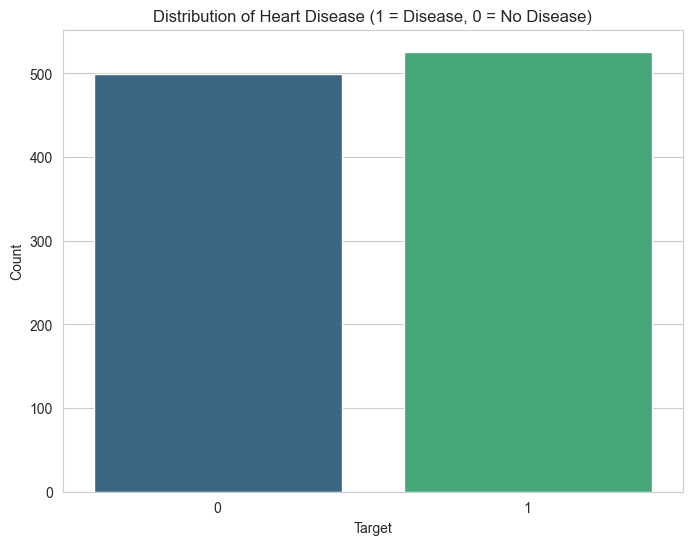

In [16]:
plt.figure(figsize=(8, 6))
sns.countplot(x='target', data=df, palette='viridis', hue='target', legend=False)
plt.title('Distribution of Heart Disease (1 = Disease, 0 = No Disease)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

**Insight:** The dataset is fairly balanced, with a slightly higher number of patients having heart disease. This is good because it means our model will have a similar number of examples for both classes to learn from, and accuracy will be a meaningful metric.

#### 2.2 Analyzing Features vs. Target

/var/folders/lz/qs53dcdj7jd9mf40vp_hwblc0000gn/T/ipykernel_20974/2434395720.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 1], data=df, x='target', y='thalach', palette='magma')


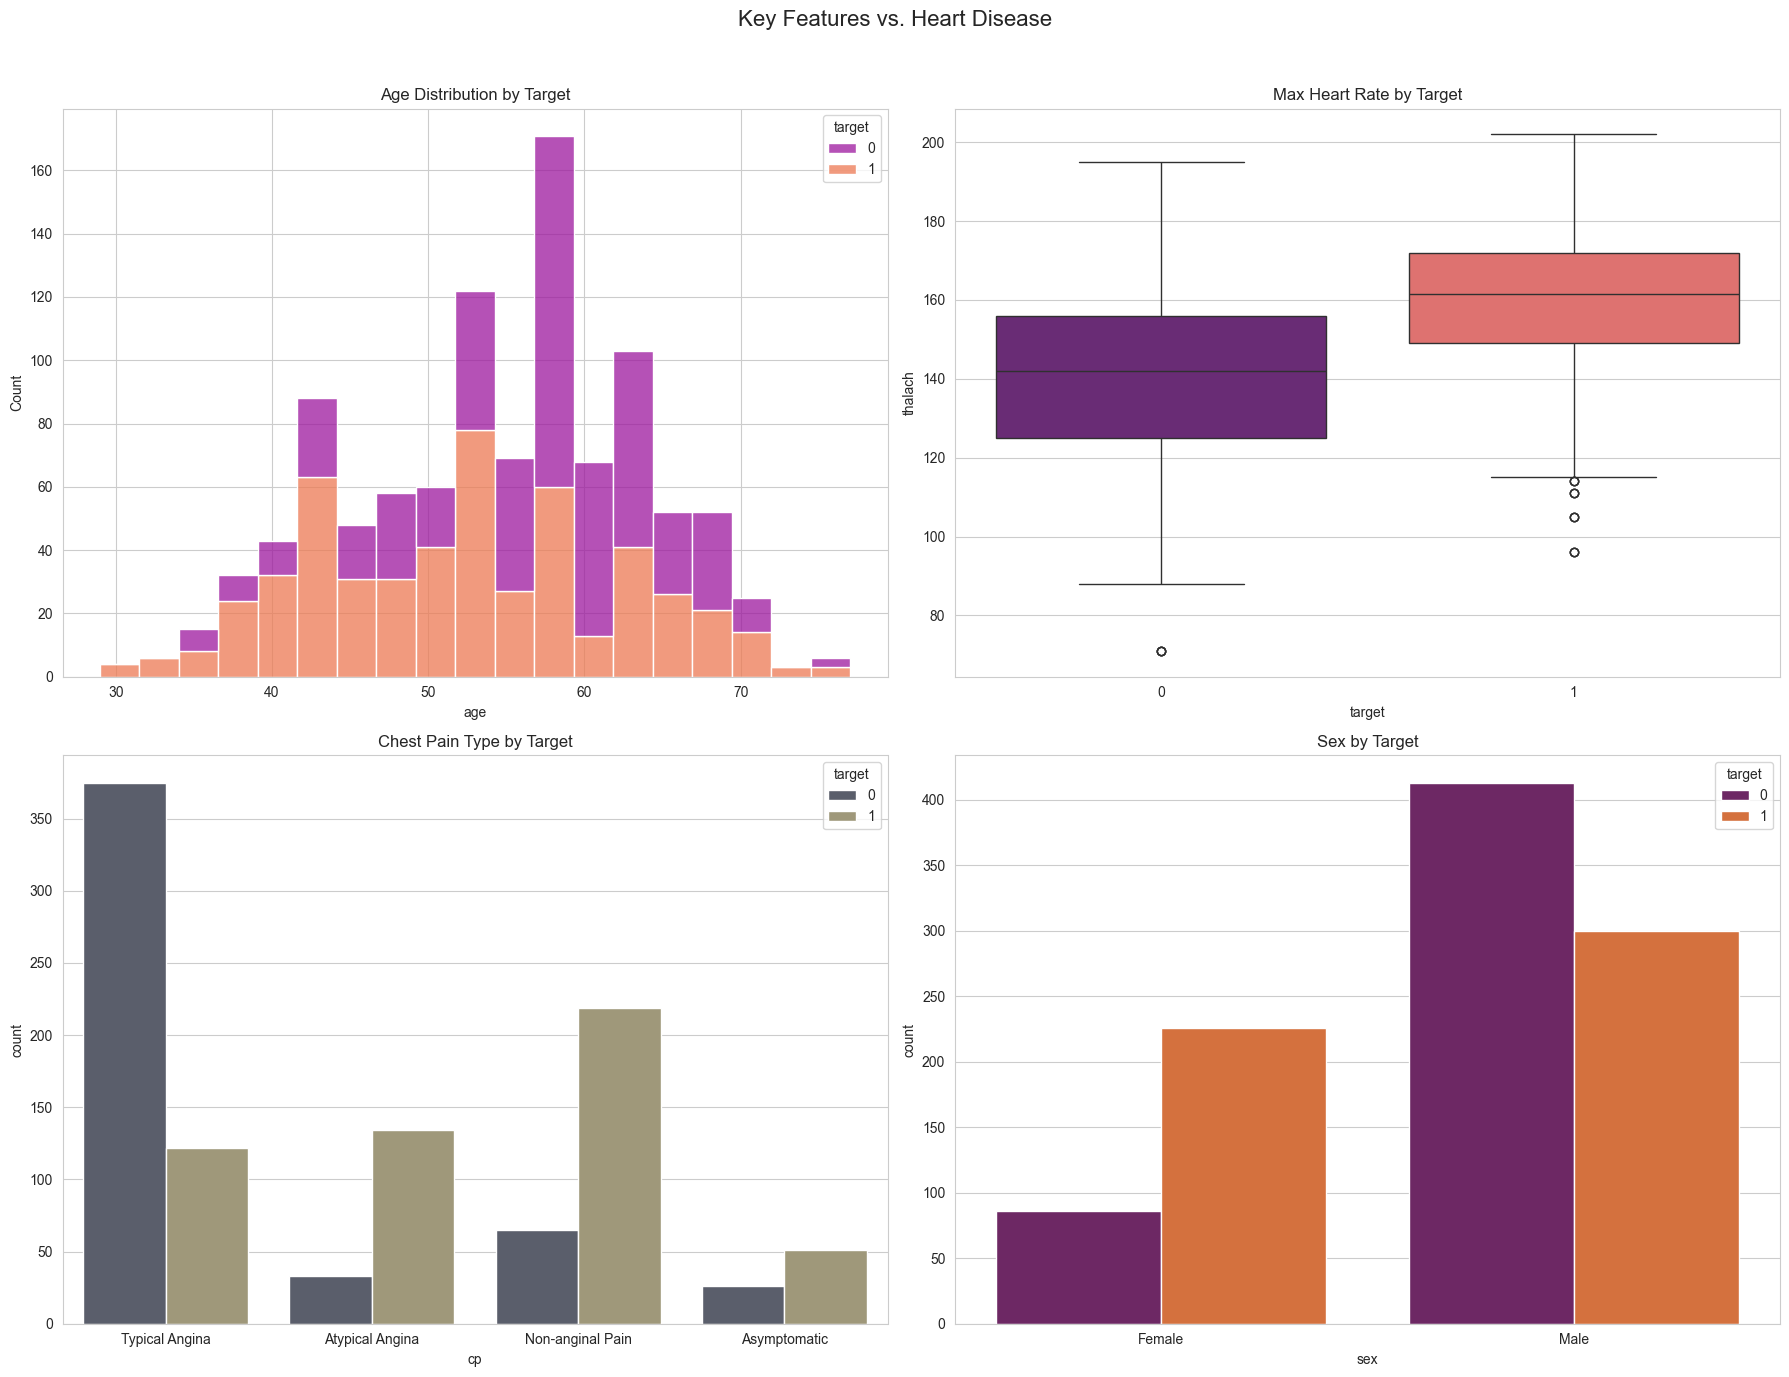

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Key Features vs. Heart Disease', fontsize=16)

# Age vs. Target
sns.histplot(ax=axes[0, 0], data=df, x='age', hue='target', multiple='stack', palette='plasma')
axes[0, 0].set_title('Age Distribution by Target')

# Max Heart Rate vs. Target
sns.boxplot(ax=axes[0, 1], data=df, x='target', y='thalach', palette='magma')
axes[0, 1].set_title('Max Heart Rate by Target')

# Chest Pain Type vs. Target
cp_plot = sns.countplot(ax=axes[1, 0], data=df, x='cp', hue='target', palette='cividis')
cp_plot.set_title('Chest Pain Type by Target')
cp_plot.set_xticks(range(len(df['cp'].unique())))
cp_plot.set_xticklabels(['Typical Angina', 'Atypical Angina', 'Non-anginal Pain', 'Asymptomatic'])

# Sex vs. Target
sex_plot = sns.countplot(ax=axes[1, 1], data=df, x='sex', hue='target', palette='inferno')
sex_plot.set_title('Sex by Target')
sex_plot.set_xticks(range(len(df['sex'].unique())))
sex_plot.set_xticklabels(['Female', 'Male'])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Insights:**
- **Max Heart Rate (`thalach`):** Patients with heart disease tend to have a lower maximum heart rate.
- **Chest Pain (`cp`):** Patients with chest pain types 1 and 2 (Atypical and Non-anginal) are more likely to have heart disease. Surprisingly, those with type 0 (Typical Angina) are less likely, and those with asymptomatic pain (type 3) are very likely to have the disease.
- **Sex:** A higher proportion of females in this dataset have heart disease compared to males.

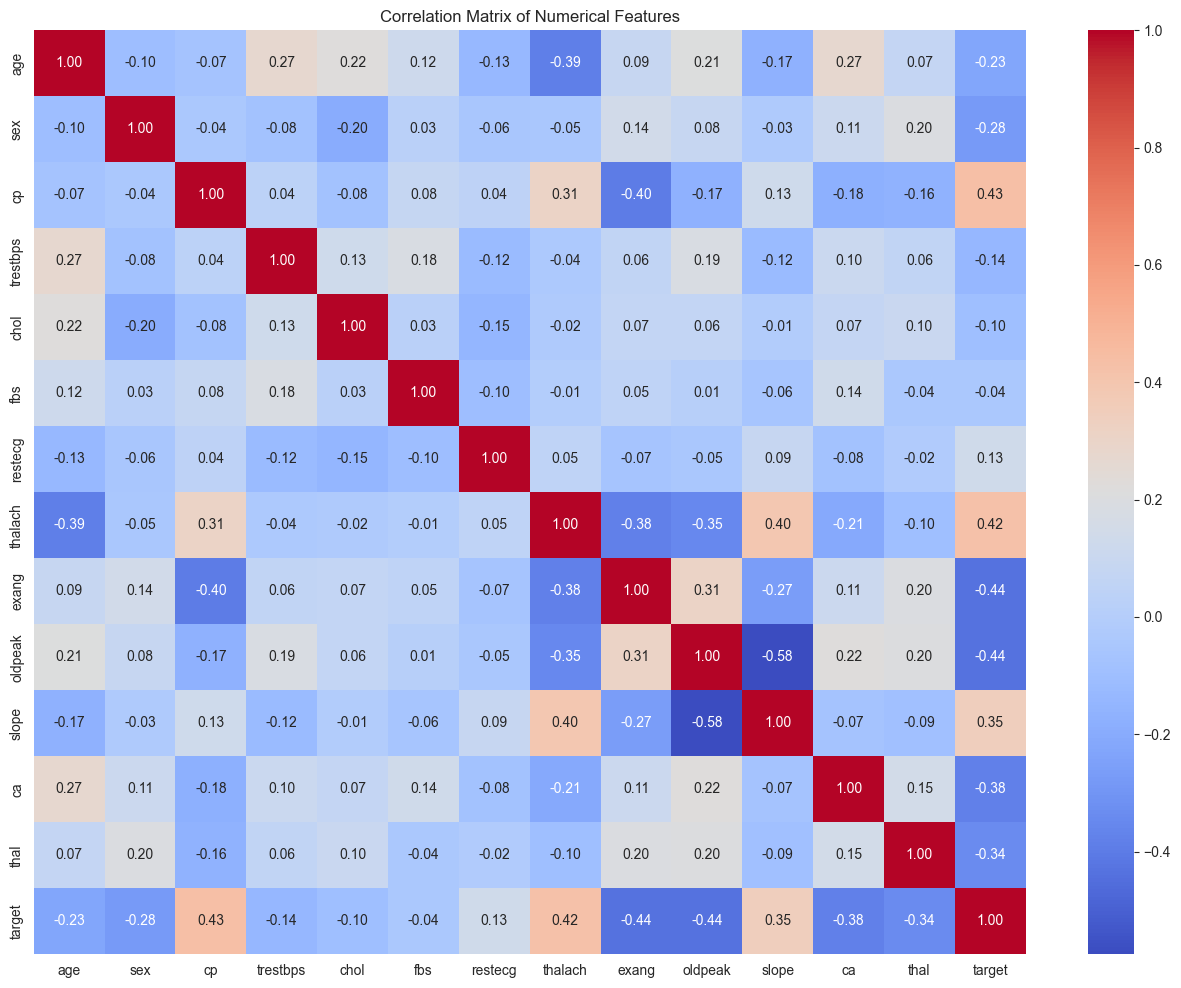

In [18]:
# Correlation Heatmap
plt.figure(figsize=(16, 12))
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=np.number)
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Step 3: Data Preprocessing


In [19]:
from sklearn.impute import SimpleImputer

# Define features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Identify categorical and numerical features
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Added imputation for categorical features
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Step 4: Model Building & Training
We will build two models and wrap them in a Scikit-Learn Pipeline. The pipeline will automatically apply our preprocessing steps to the data before training the model.

#### 4.1 Model 1: Logistic Regression (Baseline)

In [20]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Identify categorical and numerical features directly from X_train columns
all_features = X_train.columns.tolist()
categorical_features = [col for col in all_features if X_train[col].dtype == 'object']
numerical_features = [col for col in all_features if X_train[col].dtype != 'object']

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)


# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)])

# Create the Logistic Regression pipeline
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', LogisticRegression(random_state=42))])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

Numerical features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Categorical features: []


In [21]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.3481
- Mean Absolute Error: 0.2816
- R2 Score: 0.5150
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.3515
- Mean Absolute Error: 0.2799
- R2 Score: 0.5056


Lasso
Model performance for Training set
- Root Mean Squared Error: 0.4506
- Mean Absolute Error: 0.4239
- R2 Score: 0.1872
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.4538
- Mean Absolute Error: 0.4226
- R2 Score: 0.1756


Ridge
Model performance for Training set
- Root Mean Squared Error: 0.3481
- Mean Absolute Error: 0.2816
- R2 Score: 0.5150
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.3514
- Mean Absolute Error: 0.2798
- R2 Score: 0.5057


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 0.2697
- Mean Absolute Error: 0.1656
- R2 Score: 0.7089
-----------------------

In [23]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
7,CatBoosting Regressor,0.989956
6,XGBRegressor,0.982082
5,Random Forest Regressor,0.960806
4,Decision Tree,0.941429
8,AdaBoost Regressor,0.546769
2,Ridge,0.505707
0,Linear Regression,0.505617
3,K-Neighbors Regressor,0.319010
1,Lasso,0.175592


In [24]:
lin_model = CatBoostRegressor(verbose=False)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 99.00


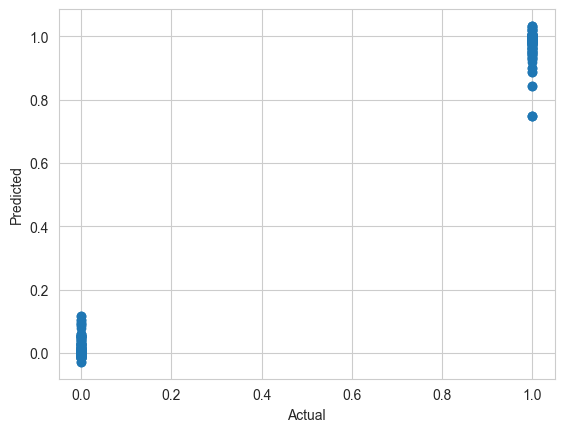

In [25]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

In [26]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
756,0,-0.002355,0.002355
353,1,0.899447,0.100553
929,0,-0.006127,0.006127
129,1,0.976536,0.023464
591,0,-0.009243,0.009243
...,...,...,...
378,0,0.010005,-0.010005
218,0,-0.028185,0.028185
564,0,-0.004630,0.004630
426,1,0.978474,0.021526


In [27]:
#Absolute Error
pred_df['Absolute Error'] = abs(pred_df['Difference'])

In [28]:
#Squared Error
pred_df['Squared Error'] = pred_df['Difference'] ** 2

In [29]:
#Percentage Error
pred_df['Percentage Error'] = (pred_df['Absolute Error'] / (pred_df['Actual Value'] + 1e-5)) * 100

In [30]:
#Predicted Category
pred_df['Predicted Class'] = [1 if val >= 0.5 else 0 for val in pred_df['Predicted Value']]

In [31]:
#Summary Statistics
summary = pred_df[['Difference', 'Absolute Error', 'Squared Error', 'Percentage Error']].describe()
print(summary)

       Difference  Absolute Error  Squared Error  Percentage Error
count  205.000000      205.000000   2.050000e+02      2.050000e+02
mean     0.004042        0.029948   2.509527e-03      1.274264e+05
std      0.050054        0.040256   8.225175e-03      2.381770e+05
min     -0.116472        0.000373   1.393329e-07      3.732695e-02
25%     -0.016168        0.006075   3.690752e-05      1.654636e+00
50%      0.001933        0.015448   2.386400e-04      2.515706e+01
75%      0.015448        0.037758   1.425686e-03      1.403199e+05
max      0.251573        0.251573   6.328904e-02      1.164719e+06


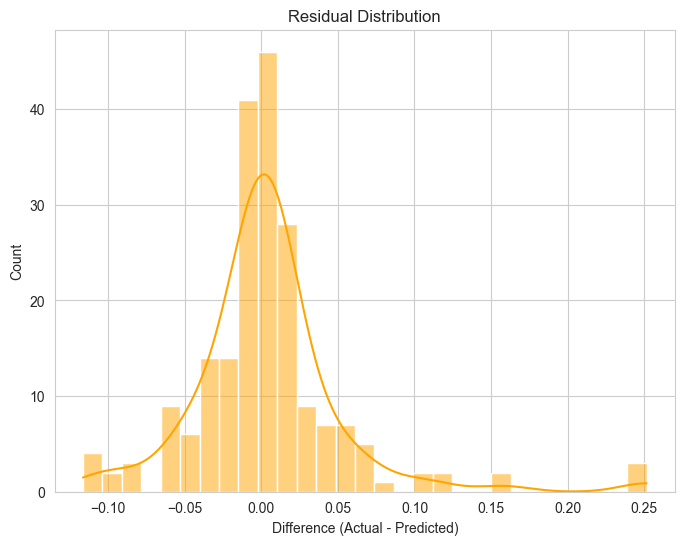

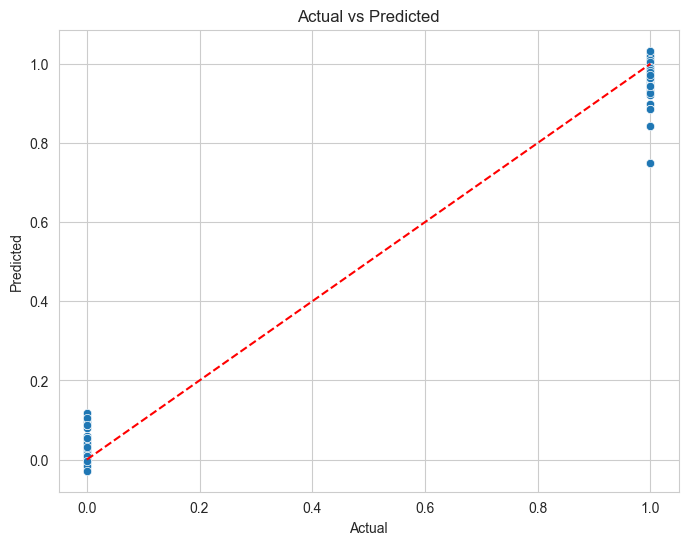

In [32]:
#Visual Enhancements

# Residual plot
plt.figure(figsize=(8,6))
sns.histplot(pred_df['Difference'], kde=True, color='orange')
plt.title('Residual Distribution')
plt.xlabel('Difference (Actual - Predicted)')
plt.show()

# Predicted vs Actual scatter
plt.figure(figsize=(8,6))
sns.scatterplot(x=pred_df['Actual Value'], y=pred_df['Predicted Value'])
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

In [33]:
pred_df.sort_values(by='Absolute Error', ascending=False).head(10)

,Actual Value,Predicted Value,Difference,Absolute Error,Squared Error,Percentage Error,Predicted Class
967,1,0.748427,0.251573,0.251573,0.063289,2.515706e+01,1
793,1,0.748427,0.251573,0.251573,0.063289,2.515706e+01,1
708,1,0.748427,0.251573,0.251573,0.063289,2.515706e+01,1
79,1,0.842008,0.157992,0.157992,0.024961,1.579899e+01,1
78,1,0.842008,0.157992,0.157992,0.024961,1.579899e+01,1
80,0,0.116472,-0.116472,0.116472,0.013566,1.164719e+06,0
957,0,0.116472,-0.116472,0.116472,0.013566,1.164719e+06,0
276,1,0.886654,0.113346,0.113346,0.012847,1.133447e+01,1
880,1,0.886654,0.113346,0.113346,0.012847,1.133447e+01,1
20,0,0.103982,-0.103982,0.103982,0.010812,1.039817e+06,0


### Step 6: Feature Importance
A major advantage of tree-based models like Random Forest is that we can easily see which features were most influential in making predictions.

In [34]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Initialize models
rf_model = RandomForestRegressor(n_estimators=500, random_state=42)
xgb_model = XGBRegressor(n_estimators=500, random_state=42)

# Train Random Forest
rf_model.fit(X_train, y_train)

# Train XGBoost
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [35]:
# CatBoost
cat_importances = lin_model.get_feature_importance()
# Random Forest
rf_importances = rf_model.feature_importances_
# XGBoost
xgb_importances = xgb_model.feature_importances_

# Feature names (must match preprocessing order)
feature_names = numerical_features + categorical_features

# Create DataFrames
feat_cat = pd.DataFrame({'Feature': feature_names, 'CatBoost': cat_importances})
feat_rf = pd.DataFrame({'Feature': feature_names, 'RandomForest': rf_importances})
feat_xgb = pd.DataFrame({'Feature': feature_names, 'XGBoost': xgb_importances})

# Merge for comparison
feat_compare = feat_cat.merge(feat_rf, on='Feature').merge(feat_xgb, on='Feature')
feat_compare = feat_compare.sort_values(by='CatBoost', ascending=False)
feat_compare

,Feature,CatBoost,RandomForest,XGBoost
11,ca,15.608701,0.116779,0.215916
2,cp,14.019038,0.282453,0.244880
12,thal,11.059965,0.079514,0.127653
0,age,10.775044,0.101258,0.027745
9,oldpeak,10.087228,0.087099,0.043815
4,chol,7.509499,0.081305,0.026795
7,thalach,7.003366,0.070337,0.019226
3,trestbps,5.157206,0.059774,0.018421
8,exang,4.714894,0.037069,0.060445
10,slope,4.586455,0.028286,0.055665


In [38]:
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier
import joblib
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),  # includes scaler + one-hot
    ('model', CatBoostClassifier(verbose=False))  # your trained classifier
])

full_pipeline.fit(X_train, y_train)
joblib.dump(full_pipeline, 'heart_disease_pipeline.pkl')

['heart_disease_pipeline.pkl']